# Heston Calibration with Neural Networks
A six-step interview walkthrough: numerical labels, PyTorch surrogate, bounded SciPy calibration.

The bundled checkpoint was trained on 50,000 numerical Heston labels. The recorded outputs
come from a complete local CPU run on macOS arm64 (Python 3.14.4, PyTorch 2.14.1).
All 11 code cells completed; the accompanying test run passed all 10 tests.
The notebook is ready to run without retraining.


## 1. SPX Data and Implied Volatility
Use a supplied snapshot of SPX option quotes; the source date is inconsistent (see `data/README.md`).
With fixed $r=0.045$, $q=0.012$, compute $C_{mid}=(bid+ask)/2$ and solve
$C_{BS}(\sigma)-C_{mid}=0$ by Brent's bracketed root finder.
Keep positive, ordered call quotes inside the pricing bounds and training domain.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
ROOT = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.data import load_market_data, generate_dataset, DOMAIN
from src.heston import heston_call_price, heston_implied_volatility, BOUNDS, PARAMETER_NAMES, R, Q
from src.black_scholes import implied_volatility
from src.calibration import calibrate_heston, features
market = load_market_data()
print(f'{len(market)} call quotes, {market.time_to_maturity.nunique()} maturities; r={R}, q={Q}')
print(market.head())

2130 call quotes, 14 maturities; r=0.045, q=0.012
   strike     bid     ask     spot  time_to_maturity option_type  moneyness  \
0  5525.0  1396.6  1400.1  6882.94          0.139726           C   0.802709   
1  5550.0  1372.5  1375.4  6882.94          0.139726           C   0.806341   
2  5575.0  1347.8  1351.3  6882.94          0.139726           C   0.809974   
3  5600.0  1323.7  1326.5  6882.94          0.139726           C   0.813606   
4  5625.0  1299.1  1302.3  6882.94          0.139726           C   0.817238   

       mid  implied_vol  
0  1398.35     0.364229  
1  1373.95     0.360055  
2  1349.55     0.355826  
3  1325.10     0.351346  
4  1300.70     0.347015  


In [2]:
row = market.iloc[0]
market_iv = implied_volatility(row.mid, row.spot, row.strike, row.time_to_maturity)
print(f'Mid = {row.mid:.4f}; IV = {market_iv:.6f} ({100*market_iv:.3f}%)')
print(pd.DataFrame(DOMAIN, index=list(PARAMETER_NAMES)+['K/S', 'T'], columns=['Lower', 'Upper']))

Mid = 1398.3500; IV = 0.364229 (36.423%)
       Lower  Upper
kappa  0.100   5.00
theta  0.005   0.15
xi     0.050   1.50
rho   -0.950  -0.05
v0     0.005   0.15
K/S    0.800   1.20
T      0.100   2.00


## 2. Heston Model and Numerical Pricing
Under the risk-neutral measure,
$$dS_t=(r-q)S_tdt+\sqrt{v_t}S_tdW_t^S,\qquad
 dv_t=\kappa(\theta-v_t)dt+\xi\sqrt{v_t}dW_t^v,\qquad d\langle W^S,W^v\rangle_t=\rho dt.$$
`kappa` is mean reversion, `theta` long-run variance, `xi` volatility of variance,
`rho` correlation, and `v0` initial variance.

With $F=S_0e^{(r-q)T}$, the CFs $\phi_j$ in `heston.py` describe $\log(S_T/F)$
under the share ($j=1$) and cash ($j=2$) measures:
$$P_j=\frac12+\frac1\pi\int_0^\infty\Re\left[\frac{e^{-iu\log(K/F)}\phi_j(u)}{iu}\right]du,
\quad C=S_0e^{-qT}P_1-Ke^{-rT}P_2.$$
The scalar reference uses `scipy.integrate.quad` on the infinite interval. Numerical
integration is an approximation with tolerance, not an algebraically exact option value.

In [3]:
true_params = np.array([1.8, .045, .35, -.65, .035])
price = heston_call_price(100, 100, 1, true_params)
iv = heston_implied_volatility(100, 100, 1, true_params)
print(f'Heston call = {price:.8f}; implied volatility = {iv:.8f}')

Heston call = 9.25773480; implied volatility = 0.19491236


## 3. Synthetic Training Data
Exactly seven features: $(\kappa,\theta,\xi,\rho,v_0,m,T)$, with $m=K/S_0$.
Parameters and moneyness are sampled uniformly, maturity log-uniformly to give short
maturities more coverage. Rates and dividends remain fixed; they are not hidden extra inputs.

The same CF is integrated in batches using Gauss-Legendre quadrature, then prices are
inverted with Brent. Comparing two resolutions rejects unstable labels; low-vega points
are excluded because $d\sigma\approx dC/vega$. These filters change the accepted distribution.
The training script generates 50,000 valid observations with seed 42. This small cell only
demonstrates label generation and does not train a second model.

In [4]:
x_demo, y_demo, generation = generate_dataset(64, seed=7)
print(generation)
print(pd.DataFrame(np.column_stack([x_demo[:5], y_demo[:5]]),
                     columns=list(PARAMETER_NAMES)+['moneyness', 'maturity', 'IV']))

{'seed': 7, 'attempted': 64, 'accepted': 64}
      kappa     theta        xi       rho        v0  moneyness  maturity  \
0  3.162968  0.135096  1.174744 -0.747314  0.048524   1.149421  0.524888   
1  4.124019  0.120575  0.728506 -0.677271  0.045372   0.901948  1.121994   
2  2.572286  0.085257  1.493475 -0.236604  0.095216   1.195584  0.403683   
3  0.885039  0.093818  0.113716 -0.917888  0.079659   0.986482  0.641416   
4  3.183209  0.079547  0.770466 -0.727237  0.006710   0.876961  1.162613   

         IV  
0  0.225151  
1  0.324798  
2  0.267721  
3  0.287987  
4  0.256332  


## 4. PyTorch Surrogate
A `7 → 128 → 128 → 128 → 1` tanh MLP predicts log-IV; exponentiation ensures positive IV.
Inputs are standardised with statistics from the 80% training split only. The remaining
10% validation split controls early stopping; the 10% test split measures final errors.
Training uses Adam and MSE in log-IV. Float64 inference preserves the finite-difference
perturbations used by SciPy. One state-dict checkpoint includes scaler buffers and metadata.

The trained checkpoint is included at `models/heston_nn.pt`. Regeneration is optional:
run `python scripts/train_model.py`. The recorded run completed 600 epochs and restored
epoch 594, selected by validation loss. Test MAE is 6.33 IV bp and RMSE is 8.86 IV bp.

In [5]:
import torch
from src.neural_network import load_model, error_metrics
torch.set_num_threads(1)
model, training = load_model()
print('Architecture:', model.layers)
print('Split counts:', training['split_counts'])
print('Test errors (IV bp):', training['test'])

Architecture: Sequential(
  (0): Linear(in_features=7, out_features=128, bias=True)
  (1): Tanh()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): Tanh()
  (4): Linear(in_features=128, out_features=128, bias=True)
  (5): Tanh()
  (6): Linear(in_features=128, out_features=1, bias=True)
)
Split counts: [40000, 5000, 5000]
Test errors (IV bp): {'mae_iv_bp': 6.333174661684843, 'rmse_iv_bp': 8.856216687190829, 'max_iv_bp': 108.92269654764696}


In [6]:
print('Numerical IV:', y_demo[0])
print('Neural IV:', model.predict(x_demo[:1])[0])
print('Demonstration errors (not the held-out test set):', error_metrics(y_demo, model.predict(x_demo)))

Numerical IV: 0.2251508480203321
Neural IV: 0.22468972258330958
Demonstration errors (not the held-out test set): {'mae_iv_bp': 5.275453674615234, 'rmse_iv_bp': 7.112773497875154, 'max_iv_bp': 20.62276543977254}


## 5. Heston Calibration
First recover a known synthetic surface, then calibrate the supplied SPX quotes.
$$\widehat\Theta=\arg\min_{\Theta\in\text{box}}\frac1N\sum_i
 (\sigma^{NN}(\Theta,m_i,T_i)-\sigma_i^{market})^2.$$
`scipy.optimize.minimize(method="L-BFGS-B")` uses numerical differences and one starting point.
Parameters are linearly scaled to a unit box for conditioning; the economic bounds remain
those used for training. The Feller margin $2\kappa\theta-\xi^2$ is reported, not constrained.
A negative margin allows the variance boundary to be attainable; it does not invalidate Heston.

In [7]:
m, t = np.meshgrid(np.linspace(.85, 1.15, 7), [.25, .75, 1.5])
synthetic = pd.DataFrame({'moneyness':m.ravel(), 'time_to_maturity':t.ravel()})
synthetic['implied_vol'] = [heston_implied_volatility(1, k, maturity, true_params)
                           for k, maturity in zip(m.ravel(), t.ravel())]
recovery = calibrate_heston(synthetic, model, initial_guess=[2.5,.06,.6,-.5,.05])
print(recovery)
print(pd.DataFrame({'True':true_params, 'Estimated':list(recovery['parameters'].values())}, index=PARAMETER_NAMES))
print('Recovery IV errors:', error_metrics(synthetic.implied_vol,
      model.predict(features(list(recovery['parameters'].values()), synthetic))))

{'parameters': {'kappa': 1.837040368132738, 'theta': 0.044720934196513525, 'xi': 0.3405836704709649, 'rho': -0.6702352936729364, 'v0': 0.03507842916707203}, 'objective': 6.79376542939572e-08, 'success': True, 'iterations': 28, 'message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'elapsed_seconds': 0.023288332973606884, 'feller_margin': 0.04831108624773152}
        True  Estimated
kappa  1.800   1.837040
theta  0.045   0.044721
xi     0.350   0.340584
rho   -0.650  -0.670235
v0     0.035   0.035078
Recovery IV errors: {'mae_iv_bp': 2.1241420747956736, 'rmse_iv_bp': 2.6064852636060922, 'max_iv_bp': 5.702593514578524}


In [8]:
fit = calibrate_heston(market, model)
print(fit)
if not fit['success']:
    raise RuntimeError(fit['message'])
params = np.array(list(fit['parameters'].values()))
market['neural_iv'] = model.predict(features(params, market))
print(pd.Series(fit['parameters'], name='SPX estimate').to_frame())
print('SPX in-sample fit (IV bp):', error_metrics(market.implied_vol, market.neural_iv))

{'parameters': {'kappa': 4.712692204727981, 'theta': 0.04907457725321868, 'xi': 1.5, 'rho': -0.7735140874251014, 'v0': 0.037474621269229375}, 'objective': 1.4976626346684415e-05, 'success': True, 'iterations': 30, 'message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'elapsed_seconds': 0.8670873330556788, 'feller_margin': -1.7874532446568705}
       SPX estimate
kappa      4.712692
theta      0.049075
xi         1.500000
rho       -0.773514
v0         0.037475
SPX in-sample fit (IV bp): {'mae_iv_bp': 27.88537385204811, 'rmse_iv_bp': 38.69964644112969, 'max_iv_bp': 293.3507555253212}


In [9]:
# Check actual Heston at fitted parameters on 30 evenly spaced quote rows.
check = market.iloc[np.linspace(0,len(market)-1,30,dtype=int)].copy()
check['direct_iv'] = [heston_implied_volatility(1,row.moneyness,row.time_to_maturity,params)
                      for row in check.itertuples()]
print('Numerical Heston vs SPX (30 quotes):', error_metrics(check.implied_vol,check.direct_iv))
print('Surrogate vs numerical Heston:', error_metrics(check.direct_iv,check.neural_iv))

Numerical Heston vs SPX (30 quotes): {'mae_iv_bp': 36.03687654011531, 'rmse_iv_bp': 60.52539370891028, 'max_iv_bp': 255.8311095173249}
Surrogate vs numerical Heston: {'mae_iv_bp': 7.297986648129727, 'rmse_iv_bp': 9.847110828598012, 'max_iv_bp': 37.519646007996286}


Matplotlib is building the font cache; this may take a moment.


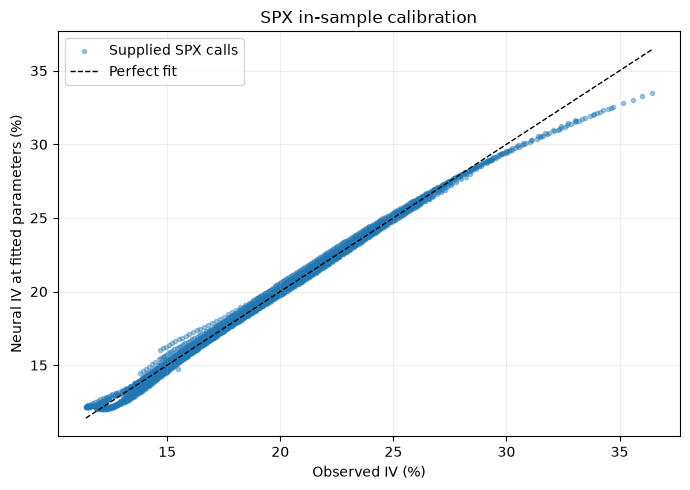

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(market.implied_vol*100,market.neural_iv*100,s=9,alpha=.4,label='Supplied SPX calls')
limits=[min(market.implied_vol.min(),market.neural_iv.min())*100,
        max(market.implied_vol.max(),market.neural_iv.max())*100]
ax.plot(limits,limits,'k--',linewidth=1,label='Perfect fit')
ax.set(xlabel='Observed IV (%)',ylabel='Neural IV at fitted parameters (%)',title='SPX in-sample calibration')
ax.legend();ax.grid(alpha=.2);fig.tight_layout()
(ROOT/'figures').mkdir(exist_ok=True)
fig.savefig(ROOT/'figures/spx_fit.png',dpi=160)
plt.show()

## 6. Accuracy and Speed Benchmark
Run the same 200 options through adaptive Heston integration + Brent inversion and through
PyTorch. Use fixed parameters, varied moneyness/maturity, CPU, one Torch thread, warm-up,
three reference repetitions, and nine groups of 100 neural batches. Report median batch time
per option: this is **throughput**, not the latency of an isolated request.

Neural timing includes validation, tensor conversion, standardisation, forward pass,
exponentiation and conversion back to NumPy. Label generation and training are offline costs.
No complete-calibration speedup is claimed. The standalone terminal run measured 3,104x
(7.37118 ms versus 0.00237440 ms per option); this notebook run measured 3,978x.
Use the standalone result as the primary benchmark, and retain both observations to show
timing variability. Performance and accuracy are separate measurements.

In [11]:
from scripts.benchmark import run_benchmark
benchmark = run_benchmark()

options: 200
exact_ms_per_option: 9.485859374981374
nn_ms_per_option: 0.002384579152567312
speedup: 3978.0014703091747
accuracy: {'mae_iv_bp': 3.803602478340114, 'rmse_iv_bp': 4.801040100429774, 'max_iv_bp': 15.49464744130008}
python: 3.14.4
platform: macOS-26.5.1-arm64-arm-64bit-Mach-O
numpy: 2.5.3
scipy: 1.18.1
torch: 2.14.1
torch_threads: 1
dtype: float64
Batched throughput: scaling, tensor conversion and exp included; training excluded.
Reference = adaptive P1/P2 integration + Brent, not a complete calibration.


**Interpretation.** SPX fit is in-sample under assumed carry and supplied maturities. A small
surrogate error does not guarantee a small market-model error, unique parameters, or an
arbitrage-free continuous surface. Inspect the success flag, active bounds and direct repricing.

The SPX fit converged in 30 iterations, with MAE 27.89 IV bp and RMSE 38.70 IV bp.
`xi = 1.5` is at its upper bound, so this is a constrained optimum within the training
domain. Widening the bound would require new labels and retraining. The Feller margin
is -1.78745; Feller positivity was not imposed. The 30-quote numerical reprice has
RMSE 60.53 IV bp against SPX, while neural-versus-numerical RMSE on those same quotes
is 9.85 IV bp. The subset has a different composition from all 2,130 fitted quotes.
